Data Preprocessing

In [ ]:
# ---------------- IMPORTS ----------------
import os
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
import pickle

# ---------------- CONFIG ----------------
# Mount Google Drive to access files
drive.mount('/content/drive')

# --- PLEASE UPDATE THESE PATHS ---
DATASET_PATH = '/content/drive/MyDrive/Final/collected_dataset2'  # Path to your raw dataset
SAVE_DIR = '/content/drive/MyDrive/Final/Processed/'               # Path to save processed data

FIXED_FRAMES = 30   # Target frames after downsampling
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------- FUNCTIONS ----------------
def fix_frame_count(seq, target=FIXED_FRAMES):
    """
    Downsample each sequence to exactly `target` frames using np.linspace.
    """
    seq = np.array(seq)
    N = len(seq)

    if N == target:
        return seq
    elif N > target:
        # Evenly sample 'target' frames from the sequence
        indices = np.linspace(0, N-1, target, dtype=int)
        return seq[indices]
    else:
        # Pad sequences shorter than target (shouldn't happen for your dataset)
        last = seq[-1]
        pad = np.tile(last, (target - N, 1))
        return np.vstack([seq, pad])

def load_data(data_path):
    """
    Load dataset and ensure each sample has fixed frame count.
    """
    X, y = [], []
    gestures = sorted(os.listdir(data_path))

    for gesture in gestures:
        gesture_dir = os.path.join(data_path, gesture)
        if not os.path.isdir(gesture_dir):
            continue

        print(f"Loading gesture: {gesture}")
        for file in os.listdir(gesture_dir):
            if file.endswith('.npy'):
                file_path = os.path.join(gesture_dir, file)
                data = np.load(file_path)          # Shape: (original_frames, 174)
                data = fix_frame_count(data, FIXED_FRAMES)
                X.append(data)
                y.append(gesture)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    return X, y

# ---------------- LOAD DATA ----------------
X, y = load_data(DATASET_PATH)
n_samples, n_frames, n_features = X.shape
print(f"Loaded data shape: {X.shape}  (Frames × Features = {n_frames} × {n_features})")

# ---------------- NORMALIZATION ----------------
X_reshaped = X.reshape(-1, n_features)           # Flatten frames for scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
X_normalized = X_scaled.reshape(n_samples, n_frames, n_features)
print(f"Data normalized with mean: {scaler.mean_.mean():.4f}, std: {scaler.scale_.mean():.4f}")

# ---------------- LABEL ENCODING ----------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)
print(f"Number of classes: {len(label_encoder.classes_)}")

# ---------------- CORRECTED DATA SPLITTING ----------------

# Step 1: Split off the final, untouched test set (20% of total data)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Step 2: Split the remaining data into training and validation sets
# We take 25% of the remaining 80% for validation (which is 20% of the total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"Final Training data shape: {X_train.shape}") # Should be ~60% of total
print(f"Validation data shape: {X_val.shape}")       # Should be ~20% of total
print(f"Final Testing data shape: {X_test.shape}")   # Should be ~20% of total

# ---------------- SAVE ALL DATA SPLITS ----------------
# Add these lines to save your newly created splits
np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(SAVE_DIR, 'X_val.npy'), X_val)
np.save(os.path.join(SAVE_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(SAVE_DIR, 'y_val.npy'), y_val)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'), y_test)

print("All data splits and encoders saved to Google Drive!")

# ---------------- SAVE SCALER & LABEL ENCODER ----------------
with open('/content/drive/MyDrive/Final/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('/content/drive/MyDrive/Final/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Scaler and label encoder saved to Google Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading gesture: bye
Loading gesture: hello
Loading gesture: i
Loading gesture: indian
Loading gesture: man
Loading gesture: thankyou
Loading gesture: woman
Loading gesture: you
Loaded data shape: (1200, 30, 174)  (Frames × Features = 30 × 174)
Data normalized with mean: 0.1754, std: 0.0484
Number of classes: 8
Final Training data shape: (720, 30, 174)
Validation data shape: (240, 30, 174)
Final Testing data shape: (240, 30, 174)
All data splits and encoders saved to Google Drive!
Scaler and label encoder saved to Google Drive!


In [ ]:
# ---------------- DATA AUGMENTATION WITH PROPER DEPTH HANDLING ----------------
def add_noise(sequence, noise_factor=0.01, z_factor=2):
    """Add Gaussian noise with depth-aware scaling"""
    noise = np.random.normal(0, noise_factor, sequence.shape)

    # Calculate depth-dependent noise scaling
    # Deeper landmarks (higher z values) get more noise
    z_coords = sequence[:, 2::3]
    depth_factor = 1 + 0.3 * np.abs(z_coords)  # Scale noise with depth

    # Apply depth-scaled noise to z-coordinates
    noise[:, 2::3] *= z_factor * depth_factor

    return sequence + noise

def depth_normalization(sequence):
    """Normalize z-coordinates relative to hand size for each frame"""
    normalized_sequence = sequence.copy()

    # Process each frame independently
    for frame_idx in range(sequence.shape[0]):
        frame = sequence[frame_idx]

        # Extract hand landmarks (first 126 values: 21 landmarks * 3 coords * 2 hands)
        left_hand = frame[0:63].reshape(21, 3)
        right_hand = frame[63:126].reshape(21, 3)

        # Calculate hand size (distance between wrist and middle finger MCP)
        def calculate_hand_size(hand_landmarks):
            wrist = hand_landmarks[0]
            middle_mcp = hand_landmarks[9]
            return np.linalg.norm(wrist - middle_mcp)

        # Normalize left hand z-coordinates
        if np.any(left_hand):
            left_hand_size = calculate_hand_size(left_hand)
            if left_hand_size > 0:
                left_hand[:, 2] /= left_hand_size  # Normalize z by hand size

        # Normalize right hand z-coordinates
        if np.any(right_hand):
            right_hand_size = calculate_hand_size(right_hand)
            if right_hand_size > 0:
                right_hand[:, 2] /= right_hand_size  # Normalize z by hand size

        # Update the frame with normalized hand landmarks
        normalized_sequence[frame_idx, 0:63] = left_hand.flatten()
        normalized_sequence[frame_idx, 63:126] = right_hand.flatten()

    return normalized_sequence

def random_scaling(sequence, xy_scale_range=(0.95, 1.05), z_scale_range=(0.97, 1.03)):
    """Apply realistic scaling with depth constraints"""
    xy_scale = np.random.uniform(xy_scale_range[0], xy_scale_range[1])
    z_scale = np.random.uniform(z_scale_range[0], z_scale_range[1])

    scaled_sequence = sequence.copy()

    # Apply scaling to x and y coordinates
    scaled_sequence[:, 0::3] *= xy_scale  # X coordinates
    scaled_sequence[:, 1::3] *= xy_scale  # Y coordinates

    # Apply depth scaling with constraints
    # Ensure z scaling doesn't create unrealistic depth relationships
    scaled_sequence[:, 2::3] *= z_scale  # Z coordinates

    # Maintain relative depth between hands and body
    # This prevents creating impossible configurations where hands are behind the body
    hand_z = scaled_sequence[:, 2:126:3]  # All z-coordinates of hands
    body_z = scaled_sequence[:, 126:138:3]  # z-coordinates of pose landmarks

    # Ensure hands aren't behind the body
    for i in range(hand_z.shape[0]):
        if np.any(hand_z[i] > body_z[i].mean()):
            # Scale hand z to be in front of body
            hand_z[i] = np.minimum(hand_z[i], body_z[i].mean() - 0.1)

    return scaled_sequence

def depth_variation(sequence, depth_shift_range=(-0.2, 0.2)):
    """Simulate realistic depth variations during signing"""
    # Create a smooth depth trajectory for the sequence
    depth_shift = np.random.uniform(depth_shift_range[0], depth_shift_range[1])

    # Apply depth shift with temporal smoothing
    # This simulates natural movement toward/away from camera
    depth_trajectory = np.linspace(0, depth_shift, sequence.shape[0])

    # Add some random fluctuation to the trajectory
    fluctuation = np.random.normal(0, 0.05, sequence.shape[0])
    depth_trajectory += fluctuation

    # Apply the depth trajectory to all z-coordinates
    modified_sequence = sequence.copy()
    for i in range(sequence.shape[0]):
        modified_sequence[i, 2::3] += depth_trajectory[i]

    return modified_sequence

def time_warp(sequence, warp_factor_range=(0.8, 1.2)):
    """Apply time warping with depth preservation"""
    warp_factor = np.random.uniform(warp_factor_range[0], warp_factor_range[1])
    orig_len = len(sequence)
    new_len = int(orig_len * warp_factor)

    if new_len < 10:
        new_len = 10

    indices = np.linspace(0, orig_len-1, new_len)
    warped_sequence = np.zeros((new_len, sequence.shape[1]))

    # Interpolate each coordinate separately
    for i in range(sequence.shape[1]):
        warped_sequence[:, i] = np.interp(indices, np.arange(orig_len), sequence[:, i])

    # Ensure depth relationships are maintained after warping
    # Re-normalize z-coordinates after interpolation
    warped_sequence = depth_normalization(warped_sequence)

    if new_len != orig_len:
        indices = np.linspace(0, new_len-1, orig_len)
        final_sequence = np.zeros((orig_len, sequence.shape[1]))
        for i in range(sequence.shape[1]):
            final_sequence[:, i] = np.interp(indices, np.arange(new_len), warped_sequence[:, i])
        return final_sequence

    return warped_sequence

def augment_sequence(sequence):
    """Apply comprehensive augmentations with proper depth handling"""
    # First, normalize depth information
    sequence = depth_normalization(sequence)

    # Add depth-aware noise
    noise_factor = np.random.uniform(0.005, 0.02)
    z_factor = np.random.uniform(1.5, 2.5)
    sequence = add_noise(sequence, noise_factor, z_factor)

    # Apply realistic scaling (70% chance)
    if np.random.rand() > 0.3:
        sequence = random_scaling(sequence)

    # Apply depth variation (60% chance)
    if np.random.rand() > 0.4:
        sequence = depth_variation(sequence)

    # Apply time warping (50% chance)
    if np.random.rand() > 0.5:
        sequence = time_warp(sequence)

    return sequence

Applying data augmentation with proper depth handling...
Original training data shape: (720, 30, 174)
Augmented training data shape: (720, 30, 174)
Data augmentation completed!


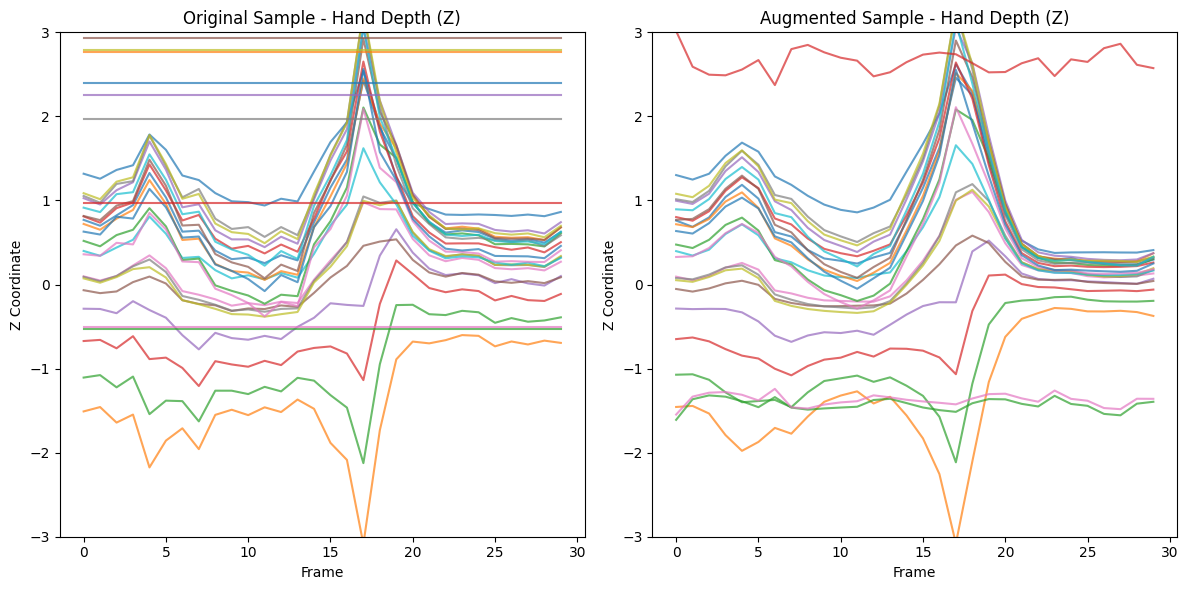

In [ ]:
# Apply augmentation to training data
print("Applying data augmentation with proper depth handling...")
X_train_aug = np.array([augment_sequence(seq) for seq in X_train])

print(f"Original training data shape: {X_train.shape}")
print(f"Augmented training data shape: {X_train_aug.shape}")
print("Data augmentation completed!")

# Visualization of depth handling
import matplotlib.pyplot as plt

# Select a random sample
sample_idx = np.random.randint(0, len(X_train))
original_sample = X_train[sample_idx]
augmented_sample = augment_sequence(original_sample.copy())

# Plot z-coordinates for all hand landmarks over time
plt.figure(figsize=(12, 6))

# Original sample
plt.subplot(1, 2, 1)
plt.plot(original_sample[:, 2:126:3], alpha=0.7)  # All z-coordinates of hands
plt.title('Original Sample - Hand Depth (Z)')
plt.xlabel('Frame')
plt.ylabel('Z Coordinate')
plt.ylim(-3, 3)  # Adjust based on your data range

# Augmented sample
plt.subplot(1, 2, 2)
plt.plot(augmented_sample[:, 2:126:3], alpha=0.7)  # All z-coordinates of hands
plt.title('Augmented Sample - Hand Depth (Z)')
plt.xlabel('Frame')
plt.ylabel('Z Coordinate')
plt.ylim(-3, 3)  # Adjust based on your data range

plt.tight_layout()
plt.show()

Model Building and Training

Training set loaded: 720 samples
Validation set loaded: 240 samples
Applying data augmentation...
Data augmentation completed!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 174)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 128)   │    122,368 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 128)   │        512 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 64)    │     41,216 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 64, 30)    │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 30)    │        930 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_vec       │ (None, 30, 64)    │          0 │ dense[0][0]       │
│ (Permute)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ attention_vec[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        264 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 167,754 (655.29 KB)

 Trainable params: 167,306 (653.54 KB)

...

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6988 - loss: 9.0521 - val_accuracy: 0.9625 - val_loss: 9.3617 - learning_rate: 5.0000e-04
Epoch 7/100
20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7708 - loss: 8.0514
Epoch 7: val_accuracy improved from 0.96250 to 0.97917, saving model to /content/drive/MyDrive/Final/sign_language_model_regularized.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7704 - loss: 8.0259 - val_accuracy: 0.9792 - val_loss: 8.5562 - learning_rate: 5.0000e-04
Epoch 8/100
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7800 - loss: 7.3083
Epoch 8: val_accuracy improved from 0.97917 to 0.99167, saving model to /content/drive/MyDrive/Final/sign_language_model_regularized.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7812 - loss: 7.2877 - val_accuracy: 0.9917 - val_loss: 7.8336 - learning_rate: 5.0000e-04
Epoch 9/100
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7878 - loss: 6.6380
Epoch 9: val_accuracy improved from 0.99167 to 0.99583, saving model to /content/drive/MyDrive/Final/sign_language_model_regularized.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7929 - loss: 6.6122 - val_accuracy: 0.9958 - val_loss: 7.1764 - learning_rate: 5.0000e-04
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8118 - loss: 5.9956
Epoch 10: val_accuracy did not improve from 0.99583
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8118 - loss: 5.9907 - val_accuracy: 0.9917 - val_loss: 6.5839 - learning_rate: 5.0000e-04
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8382 - loss: 5.4372
Epoch 11: val_accuracy did not improve from 0.99583
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8385 - loss: 5.4324 - val_accuracy: 0.9958 - val_loss: 6.0450 - learning_rate: 5.0000e-04
Epoch 12/100
20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8869 - loss: 4.9211
Epoch 12: val_accuracy improved from 0.99583 to 1.00000, saving model to /content/drive/MyDrive/Final/sign_language_model_regularized.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8835 - loss: 4.9096 - val_accuracy: 1.0000 - val_loss: 5.5476 - learning_rate: 5.0000e-04
Epoch 13/100
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9062 - loss: 4.4779
Epoch 13: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9041 - loss: 4.4721 - val_accuracy: 1.0000 - val_loss: 5.0942 - learning_rate: 5.0000e-04
Epoch 14/100
20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8749 - loss: 4.1554
Epoch 14: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8752 - loss: 4.1432 - val_accuracy: 1.0000 - val_loss: 4.6737 - learning_rate: 5.0000e-04
Epoch 15/100
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9154 - loss: 3.8166
Epoch 15: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9134 - loss: 3.8127 - val_accuracy: 1.0000 - val_loss: 4.2868 - learning_rate: 5.0000e-04
Epoch 1

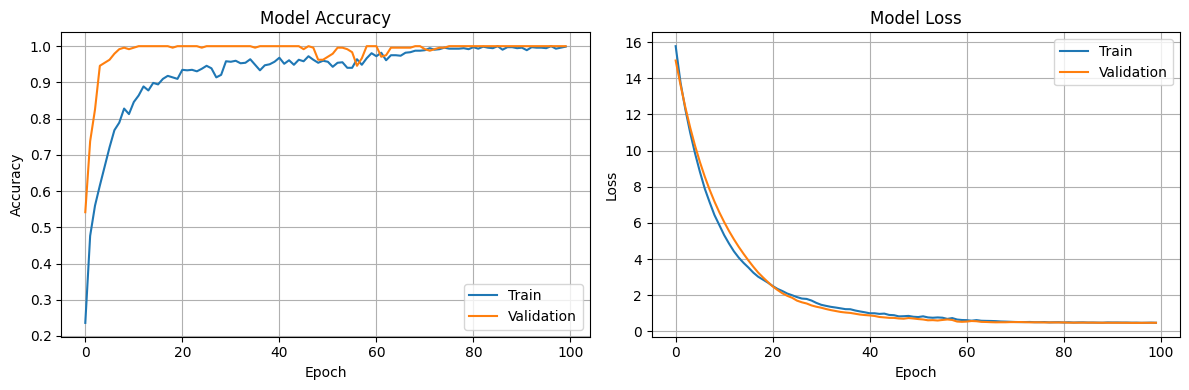


Validation Loss: 0.4698
Validation Accuracy: 1.0000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

Classification Report:
              precision    recall  f1-score   support

         bye       1.00      1.00      1.00        30
       hello       1.00      1.00      1.00        30
           i       1.00      1.00      1.00        30
      indian       1.00      1.00      1.00        30
         man       1.00      1.00      1.00        30
    thankyou       1.00      1.00      1.00        30
       woman       1.00      1.00      1.00        30
         you       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



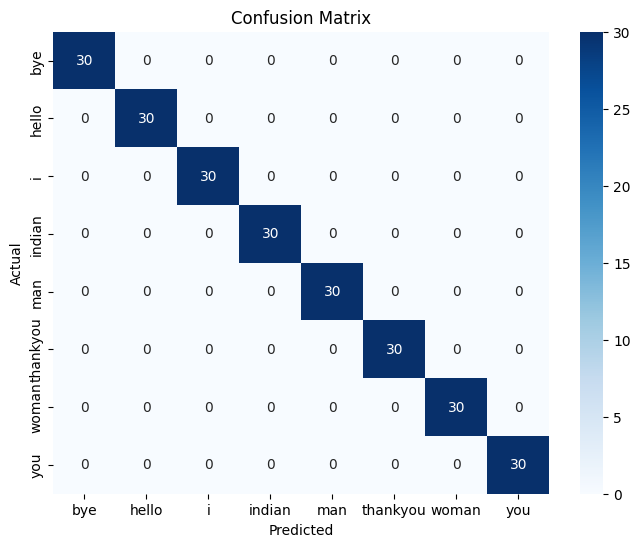

In [ ]:
# ---------------- IMPORTS ----------------
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Permute, Multiply, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ---------------- LOAD PROCESSED DATA ----------------
# Define the path where you saved the processed data
PROCESSED_DATA_DIR = '/content/drive/MyDrive/Final/Processed/'

# Load the training and validation splits from the files
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_DATA_DIR, 'y_train.npy'))
X_val = np.load(os.path.join(PROCESSED_DATA_DIR, 'X_val.npy'))
y_val = np.load(os.path.join(PROCESSED_DATA_DIR, 'y_val.npy'))

print(f"Training set loaded: {X_train.shape[0]} samples")
print(f"Validation set loaded: {X_val.shape[0]} samples")

# Apply augmentation ONLY to the loaded training data
# This line remains the same, but now it uses the correctly loaded data
print("Applying data augmentation...")
X_train_aug = np.array([augment_sequence(seq) for seq in X_train])
print("Data augmentation completed!")

# ---------------- MODEL ARCHITECTURE (WITH INCREASED REGULARIZATION) ----------------
def build_bilstm_attention_model(input_shape, num_classes):
    """
    Two-BiLSTM model with attention - with increased regularization
    """
    inputs = Input(shape=input_shape)

    # First BiLSTM with increased regularization
    x = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.02)))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)  # Increased dropout

    # Second BiLSTM with increased regularization
    x = Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=l2(0.02)))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)  # Increased dropout

    # Attention mechanism
    attention = Permute((2,1))(x)
    attention = Dense(x.shape[1], activation='softmax')(attention)
    attention = Permute((2,1), name='attention_vec')(attention)
    x = Multiply()([x, attention])

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    # Dense layer with increased regularization
    x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)  # Increased dropout

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# ---------------- BUILD THE MODEL ----------------
input_shape = (X_train_aug.shape[1], 174)  # Updated input features to 174
num_classes = y_train.shape[1]  # Number of gesture classes

model = build_bilstm_attention_model(input_shape, num_classes)
model.summary()

# ---------------- COMPILE THE MODEL ----------------
model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------- CALLBACKS ----------------
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Final/sign_language_model_regularized.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,  # Reduced patience
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# ---------------- TRAINING ----------------
print("Starting model training...")
history = model.fit(
    X_train_aug, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,  # Larger batch size
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)
print("Model training completed!")

# ---------------- SAVE TRAINING HISTORY ----------------
with open('/content/drive/MyDrive/training_history_regularized.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("Training history saved to Google Drive!")

# ---------------- EVALUATION ----------------
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_plots_regularized.png')
plt.show()

# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# Make predictions
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# Load label encoder
with open('/content/drive/MyDrive/Final/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/confusion_matrix_regularized.png')
plt.show()


Test

Loading the best trained model...


Model loaded successfully!

Loading the untouched test data...
Test data loaded: 240 samples
Loading the label encoder...

--- FINAL EVALUATION ON TEST SET ---
Final Test Loss: 5.5533
Final Test Accuracy: 0.9958
------------------------------------

Generating predictions and detailed report...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Classification Report on Test Set:
              precision    recall  f1-score   support

         bye       1.00      1.00      1.00        30
       hello       1.00      1.00      1.00        30
           i       1.00      1.00      1.00        30
      indian       1.00      1.00      1.00        30
         man       1.00      0.97      0.98        30
    thankyou       1.00      1.00      1.00        30
       woman       0.97      1.00      0.98        30
         you       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00  

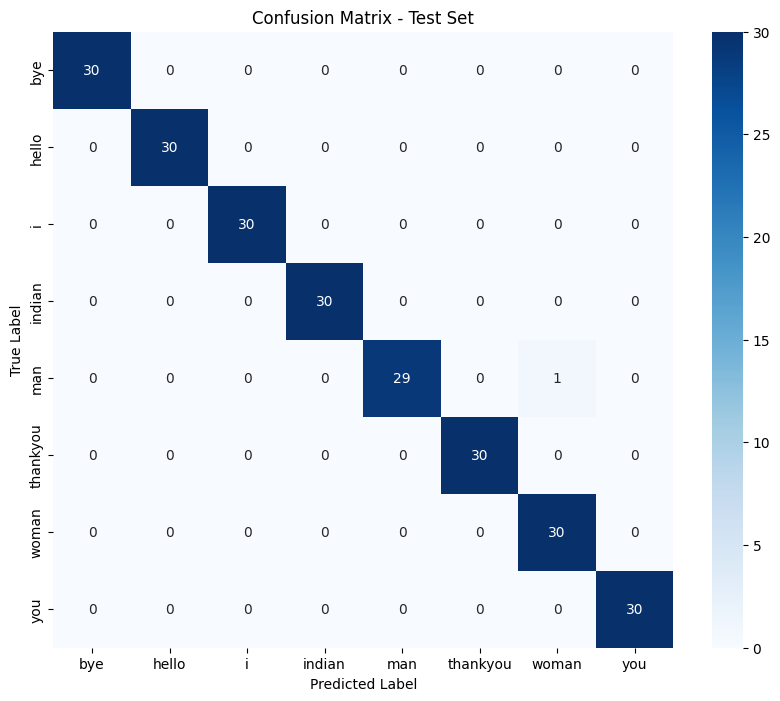


Final evaluation complete!


In [ ]:
# ---------------- IMPORTS ----------------
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import pickle
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
# Paths to your saved files
MODEL_PATH = '/content/drive/MyDrive/Final/sign_language_model_regularized.h5'
PROCESSED_DATA_DIR = '/content/drive/MyDrive/Final/Processed/'
SCALER_PATH = '/content/drive/MyDrive/Final/scaler.pkl'
LABEL_ENCODER_PATH = '/content/drive/MyDrive/Final/label_encoder.pkl'

# ---------------- LOAD THE FINAL MODEL ----------------
print("Loading the best trained model...")
model = load_model(MODEL_PATH)
print("Model loaded successfully!")

# ---------------- LOAD THE TEST DATA ----------------
print("\nLoading the untouched test data...")
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DATA_DIR, 'y_test.npy'))
print(f"Test data loaded: {X_test.shape[0]} samples")

# ---------------- LOAD THE LABEL ENCODER ----------------
print("Loading the label encoder...")
with open(LABEL_ENCODER_PATH, 'rb') as f:
    label_encoder = pickle.load(f)
class_names = label_encoder.classes_

# ---------------- FINAL EVALUATION ----------------
print("\n--- FINAL EVALUATION ON TEST SET ---")
# This is the moment of truth!
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print("------------------------------------\n")

# ---------------- DETAILED ANALYSIS ----------------
# Get predictions for the test set
print("Generating predictions and detailed report...")
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print the Classification Report
print("Classification Report on Test Set:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Generate and plot the Confusion Matrix
print("Generating Confusion Matrix...")
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

print("\nFinal evaluation complete!")

K Cross Validation

Step 1: Loading raw data...
Loaded raw data shape: (1200, 30, 174)
Step 2: Loading saved preprocessing tools...
Step 3: Preprocessing data...
Preprocessed data shape: (1200, 30, 174)
Labels shape: (1200, 8)

Step 4: Starting K-Fold Cross-Validation...
------------------------------------------------------------------------
Training for fold 1 ...
Score for fold 1: loss of 0.2587603032588959; compile_metrics of 100.0%
------------------------------------------------------------------------
Training for fold 2 ...
Score for fold 2: loss of 0.24515874683856964; compile_metrics of 100.0%
------------------------------------------------------------------------
Training for fold 3 ...
Score for fold 3: loss of 0.2929762303829193; compile_metrics of 99.16666746139526%
------------------------------------------------------------------------
Training for fold 4 ...
Score for fold 4: loss of 0.2509550452232361; compile_metrics of 100.0%
-----------------------------------------------------------

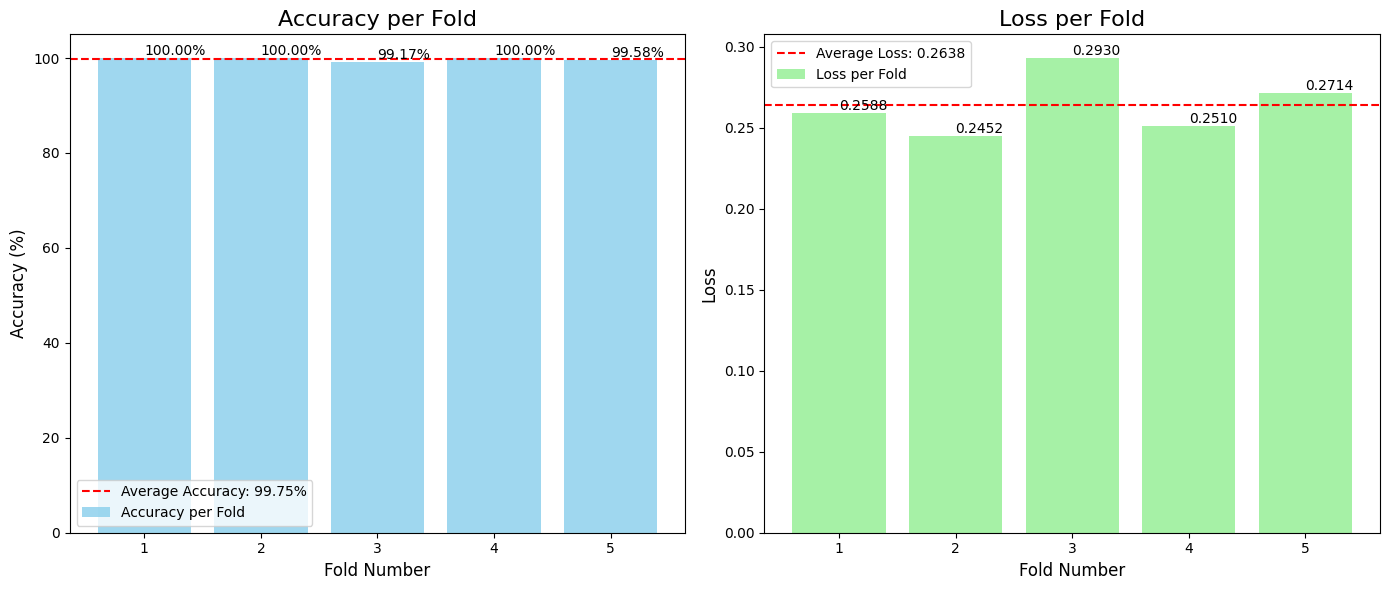

K-Fold plots generated!


In [ ]:
# ---------------- IMPORTS ----------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Permute, Multiply, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
# --- PLEASE UPDATE THESE PATHS ---
DATASET_PATH = '/content/drive/MyDrive/Final/collected_dataset2'
SCALER_PATH = '/content/drive/MyDrive/Final/scaler.pkl'
LABEL_ENCODER_PATH = '/content/drive/MyDrive/Final/label_encoder.pkl'

FIXED_FRAMES = 30

# ---------------- FUNCTIONS ----------------
def fix_frame_count(seq, target=FIXED_FRAMES):
    """Downsample each sequence to exactly `target` frames using np.linspace."""
    seq = np.array(seq)
    N = len(seq)
    if N == target:
        return seq
    elif N > target:
        indices = np.linspace(0, N-1, target, dtype=int)
        return seq[indices]
    else:
        last = seq[-1]
        pad = np.tile(last, (target - N, 1))
        return np.vstack([seq, pad])

def load_data(data_path):
    """Load dataset and ensure each sample has fixed frame count."""
    X, y = [], []
    gestures = sorted(os.listdir(data_path))
    for gesture in gestures:
        gesture_dir = os.path.join(data_path, gesture)
        if not os.path.isdir(gesture_dir):
            continue
        for file in os.listdir(gesture_dir):
            if file.endswith('.npy'):
                file_path = os.path.join(gesture_dir, file)
                data = np.load(file_path)
                data = fix_frame_count(data, FIXED_FRAMES)
                X.append(data)
                y.append(gesture)
    return np.array(X, dtype=np.float32), np.array(y)

def build_bilstm_attention_model(input_shape, num_classes):
    """Two-BiLSTM model with attention."""
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.02)))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=l2(0.02)))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    attention = Permute((2,1))(x)
    attention = Dense(x.shape[1], activation='softmax')(attention)
    attention = Permute((2,1), name='attention_vec')(attention)
    x = Multiply()([x, attention])
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(x) # <-- This line was corrected
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

# ---------------- AUGMENTATION FUNCTIONS ----------------
def add_noise(sequence, noise_factor=0.01, z_factor=2):
    """Add Gaussian noise with depth-aware scaling"""
    noise = np.random.normal(0, noise_factor, sequence.shape)
    z_coords = sequence[:, 2::3]
    depth_factor = 1 + 0.3 * np.abs(z_coords)
    noise[:, 2::3] *= z_factor * depth_factor
    return sequence + noise

def depth_normalization(sequence):
    """Normalize z-coordinates relative to hand size for each frame"""
    normalized_sequence = sequence.copy()
    for frame_idx in range(sequence.shape[0]):
        frame = sequence[frame_idx]
        left_hand = frame[0:63].reshape(21, 3)
        right_hand = frame[63:126].reshape(21, 3)
        def calculate_hand_size(hand_landmarks):
            wrist = hand_landmarks[0]
            middle_mcp = hand_landmarks[9]
            return np.linalg.norm(wrist - middle_mcp)
        if np.any(left_hand):
            left_hand_size = calculate_hand_size(left_hand)
            if left_hand_size > 0:
                left_hand[:, 2] /= left_hand_size
        if np.any(right_hand):
            right_hand_size = calculate_hand_size(right_hand)
            if right_hand_size > 0:
                right_hand[:, 2] /= right_hand_size
        normalized_sequence[frame_idx, 0:63] = left_hand.flatten()
        normalized_sequence[frame_idx, 63:126] = right_hand.flatten()
    return normalized_sequence

def random_scaling(sequence, xy_scale_range=(0.95, 1.05), z_scale_range=(0.97, 1.03)):
    """Apply realistic scaling with depth constraints"""
    xy_scale = np.random.uniform(xy_scale_range[0], xy_scale_range[1])
    z_scale = np.random.uniform(z_scale_range[0], z_scale_range[1])
    scaled_sequence = sequence.copy()
    scaled_sequence[:, 0::3] *= xy_scale
    scaled_sequence[:, 1::3] *= xy_scale
    scaled_sequence[:, 2::3] *= z_scale
    hand_z = scaled_sequence[:, 2:126:3]
    body_z = scaled_sequence[:, 126:138:3]
    for i in range(hand_z.shape[0]):
        if np.any(hand_z[i] > body_z[i].mean()):
            hand_z[i] = np.minimum(hand_z[i], body_z[i].mean() - 0.1)
    return scaled_sequence

def depth_variation(sequence, depth_shift_range=(-0.2, 0.2)):
    """Simulate realistic depth variations during signing"""
    depth_shift = np.random.uniform(depth_shift_range[0], depth_shift_range[1])
    depth_trajectory = np.linspace(0, depth_shift, sequence.shape[0])
    fluctuation = np.random.normal(0, 0.05, sequence.shape[0])
    depth_trajectory += fluctuation
    modified_sequence = sequence.copy()
    for i in range(sequence.shape[0]):
        modified_sequence[i, 2::3] += depth_trajectory[i]
    return modified_sequence

def time_warp(sequence, warp_factor_range=(0.8, 1.2)):
    """Apply time warping with depth preservation"""
    warp_factor = np.random.uniform(warp_factor_range[0], warp_factor_range[1])
    orig_len = len(sequence)
    new_len = int(orig_len * warp_factor)
    if new_len < 10:
        new_len = 10
    indices = np.linspace(0, orig_len-1, new_len)
    warped_sequence = np.zeros((new_len, sequence.shape[1]))
    for i in range(sequence.shape[1]):
        warped_sequence[:, i] = np.interp(indices, np.arange(orig_len), sequence[:, i])
    warped_sequence = depth_normalization(warped_sequence)
    if new_len != orig_len:
        indices = np.linspace(0, new_len-1, orig_len)
        final_sequence = np.zeros((orig_len, sequence.shape[1]))
        for i in range(sequence.shape[1]):
            final_sequence[:, i] = np.interp(indices, np.arange(new_len), warped_sequence[:, i])
        return final_sequence
    return warped_sequence

def augment_sequence(sequence):
    """Apply comprehensive augmentations with proper depth handling"""
    sequence = depth_normalization(sequence)
    noise_factor = np.random.uniform(0.005, 0.02)
    z_factor = np.random.uniform(1.5, 2.5)
    sequence = add_noise(sequence, noise_factor, z_factor)
    if np.random.rand() > 0.3:
        sequence = random_scaling(sequence)
    if np.random.rand() > 0.4:
        sequence = depth_variation(sequence)
    if np.random.rand() > 0.5:
        sequence = time_warp(sequence)
    return sequence

# ---------------- STEP 1: LOAD AND PREPROCESS DATA ----------------
print("Step 1: Loading raw data...")
X_raw, y_raw = load_data(DATASET_PATH)
n_samples, n_frames, n_features = X_raw.shape
print(f"Loaded raw data shape: {X_raw.shape}")

print("Step 2: Loading saved preprocessing tools...")
with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
with open(LABEL_ENCODER_PATH, 'rb') as f:
    label_encoder = pickle.load(f)

print("Step 3: Preprocessing data...")
X_reshaped = X_raw.reshape(-1, n_features)
X_normalized = scaler.transform(X_reshaped)
X_normalized = X_normalized.reshape(n_samples, n_frames, n_features)
y_encoded = label_encoder.transform(y_raw)
y_categorical = to_categorical(y_encoded)
print(f"Preprocessed data shape: {X_normalized.shape}")
print(f"Labels shape: {y_categorical.shape}")


# ---------------- STEP 2: K-FOLD CROSS-VALIDATION ----------------
print("\nStep 4: Starting K-Fold Cross-Validation...")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
accuracy_per_fold = []
loss_per_fold = []
fold_no = 1

for train_index, test_index in skf.split(X_normalized, np.argmax(y_categorical, axis=1)):
    print(f'------------------------------------------------------------------------')
    print(f'Training for fold {fold_no} ...')
    X_train_fold, X_test_fold = X_normalized[train_index], X_normalized[test_index]
    y_train_fold, y_test_fold = y_categorical[train_index], y_categorical[test_index]
    X_train_aug_fold = np.array([augment_sequence(seq) for seq in X_train_fold])
    input_shape = (X_train_aug_fold.shape[1], X_train_aug_fold.shape[2])
    num_classes = y_train_fold.shape[1]
    model = build_bilstm_attention_model(input_shape, num_classes)
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_aug_fold, y_train_fold,
                        batch_size=32,
                        epochs=100,
                        verbose=0)
    scores = model.evaluate(X_test_fold, y_test_fold, verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
    accuracy_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])
    fold_no = fold_no + 1

# --- AFTER ALL FOLDS ARE COMPLETE ---
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(accuracy_per_fold)):
    print('------------------------------------------------------------------------')
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {accuracy_per_fold[i]}%')

print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(accuracy_per_fold):.2f} (+- {np.std(accuracy_per_fold):.2f})')
print(f'> Loss: {np.mean(loss_per_fold):.2f}')
print('------------------------------------------------------------------------')


# ---------------- STEP 3: VISUALIZATION ----------------
print("\nStep 5: Generating K-Fold results plots...")
fold_numbers = range(1, n_splits + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot for Accuracy ---
bars1 = ax1.bar(fold_numbers, accuracy_per_fold, color='skyblue', alpha=0.8, label='Accuracy per Fold')
ax1.axhline(y=np.mean(accuracy_per_fold), color='r', linestyle='--', label=f'Average Accuracy: {np.mean(accuracy_per_fold):.2f}%')
ax1.set_title('Accuracy per Fold', fontsize=16)
ax1.set_xlabel('Fold Number', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_xticks(fold_numbers)
ax1.legend()
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}%', va='bottom')

# --- Plot for Loss ---
bars2 = ax2.bar(fold_numbers, loss_per_fold, color='lightgreen', alpha=0.8, label='Loss per Fold')
ax2.axhline(y=np.mean(loss_per_fold), color='r', linestyle='--', label=f'Average Loss: {np.mean(loss_per_fold):.4f}')
ax2.set_title('Loss per Fold', fontsize=16)
ax2.set_xlabel('Fold Number', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_xticks(fold_numbers)
ax2.legend()
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom')

plt.tight_layout()
plt.show()
print("K-Fold plots generated!")